### Блок 6. Гетерогенность динамики импорта по HS-кодам

In [2]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory


#### Подготовка и вспомогательный функции 

In [3]:
hs_data = pd.read_excel('data/final_data.xlsx')
hs_data["rep_date"] = pd.to_datetime(hs_data["rep_date"])
hs_data = hs_data.sort_values(["rep_date", "country", "hs"]).reset_index(drop=True)

shock_date = pd.Timestamp("2022-02-01")

save_dir = "figures/eda_block_6"
os.makedirs(save_dir, exist_ok=True)

In [4]:
def human_format(x, pos):
    abs_x = abs(x)
    if abs_x >= 1e9:
        return f"{x/1e9:.1f}B"
    elif abs_x >= 1e6:
        return f"{x/1e6:.1f}M"
    elif abs_x >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

def apply_style(ax, title, ylabel=None, xlabel=None, shade_post=False, top=False, post_sanctions=True):
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12, labelpad=15)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12, labelpad=15)

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.5)
    ax.spines["bottom"].set_alpha(0.5)
    ax.tick_params(axis="both", labelsize=11)

    if shade_post:
        # правая граница именно текущей оси
        x_left = mdates.date2num(shock_date)
        x_right = ax.get_xlim()[1]

        # красим до конца графика
        ax.axvspan(x_left, x_right, alpha=0.08, color="#B22222")
        ax.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

        # X в координатах данных, Y в долях оси
        trans = blended_transform_factory(ax.transData, ax.transAxes)

        # подпись чуть левее правого края красной зоны
        x_text = x_right - 0.02 * (x_right - x_left)

        if top:
            if post_sanctions:
                ax.text(
                    x_text, 0.94,
                    "Постсанкционный период",
                    transform=trans,
                    color="#8B0000",
                    fontsize=10,
                    ha="right",
                    va="top",
                    linespacing=1.0
                )
        else: 
            if post_sanctions: 
                ax.text(
                    x_right - 0.1 * (x_right - x_left), 0.04,
                    "Постсанкционный период",
                    transform=trans,
                    color="#8B0000",
                    fontsize=10,
                    ha="right",
                    va="bottom",
                    linespacing=1.0
                )

def save_figure(fig, filename):
    fig.savefig(os.path.join(save_dir, f"{filename}.png"), dpi=400, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [5]:
# МЕСЯЧНЫЕ РЯДЫ ПО HS

hs_month = (
    hs_data.groupby(["rep_date", "hs"], as_index=False)["value"]
    .sum()
    .sort_values(["hs", "rep_date"])
)

hs_month["period"] = np.where(
    hs_month["rep_date"] < shock_date,
    "2019–2021",
    "2022–2025"
)

# Общий импорт по месяцу
month_total = (
    hs_month.groupby("rep_date", as_index=False)["value"]
    .sum()
    .rename(columns={"value": "total_import"})
)

hs_month = hs_month.merge(month_total, on="rep_date", how="left")

# Доля HS в общем импорте месяца
hs_month["share_pct"] = np.where(
    hs_month["total_import"] > 0,
    hs_month["value"] / hs_month["total_import"] * 100,
    0
)

# Pivot для уровней
hs_levels = (
    hs_month.pivot(index="rep_date", columns="hs", values="value")
    .fillna(0)
    .sort_index(axis=1)
)

# Pivot для долей
hs_shares = (
    hs_month.pivot(index="rep_date", columns="hs", values="share_pct")
    .fillna(0)
    .sort_index(axis=1)
)

display(hs_month.head())
display(hs_levels.head())
display(hs_shares.head())

,rep_date,hs,value,period,total_import,share_pct
0,2019-01-01,9018,9.133090e+07,2019–2021,2.631455e+08,34.707382
1,2019-02-01,9018,1.117062e+08,2019–2021,2.988145e+08,37.383125
2,2019-03-01,9018,1.373245e+08,2019–2021,3.797893e+08,36.158078
3,2019-04-01,9018,1.304719e+08,2019–2021,3.531492e+08,36.945267
4,2019-05-01,9018,1.392405e+08,2019–2021,3.480698e+08,40.003603


hs,9018,9019,9020,9021,9022,9025,9027,9030,9031
rep_date,,,,,,,,,
2019-01-01,9.133090e+07,8.638801e+06,2.331416e+06,4.790242e+07,2.386126e+07,5.624468e+06,4.304866e+07,1.134355e+07,2.906398e+07
2019-02-01,1.117062e+08,1.119796e+07,1.645390e+06,5.430400e+07,2.638383e+07,6.894746e+06,4.064781e+07,1.386822e+07,3.216633e+07
2019-03-01,1.373245e+08,1.047933e+07,3.304014e+06,6.990167e+07,3.714359e+07,6.493110e+06,5.335673e+07,1.966997e+07,4.211638e+07
2019-04-01,1.304719e+08,1.315472e+07,2.611289e+06,7.267867e+07,2.944724e+07,7.327956e+06,4.242350e+07,1.245393e+07,4.257998e+07
2019-05-01,1.392405e+08,1.319846e+07,2.670749e+06,6.716000e+07,2.904730e+07,6.241610e+06,3.815470e+07,1.431733e+07,3.803922e+07


hs,9018,9019,9020,9021,9022,9025,9027,9030,9031
rep_date,,,,,,,,,
2019-01-01,34.707382,3.282900,0.885980,18.203779,9.067708,2.137399,16.359266,4.310753,11.044834
2019-02-01,37.383125,3.747462,0.550639,18.173150,8.829501,2.307367,13.603026,4.641081,10.764650
2019-03-01,36.158078,2.759249,0.869960,18.405381,9.780051,1.709661,14.049035,5.179179,11.089406
2019-04-01,36.945267,3.724974,0.739430,20.580159,8.338470,2.075031,12.012912,3.526536,12.057221
2019-05-01,40.003603,3.791901,0.767302,19.294978,8.345249,1.793206,10.961794,4.113349,10.928616


#### ГРАФИК 1. SMALL MULTIPLES ПО HS-КОДАМ

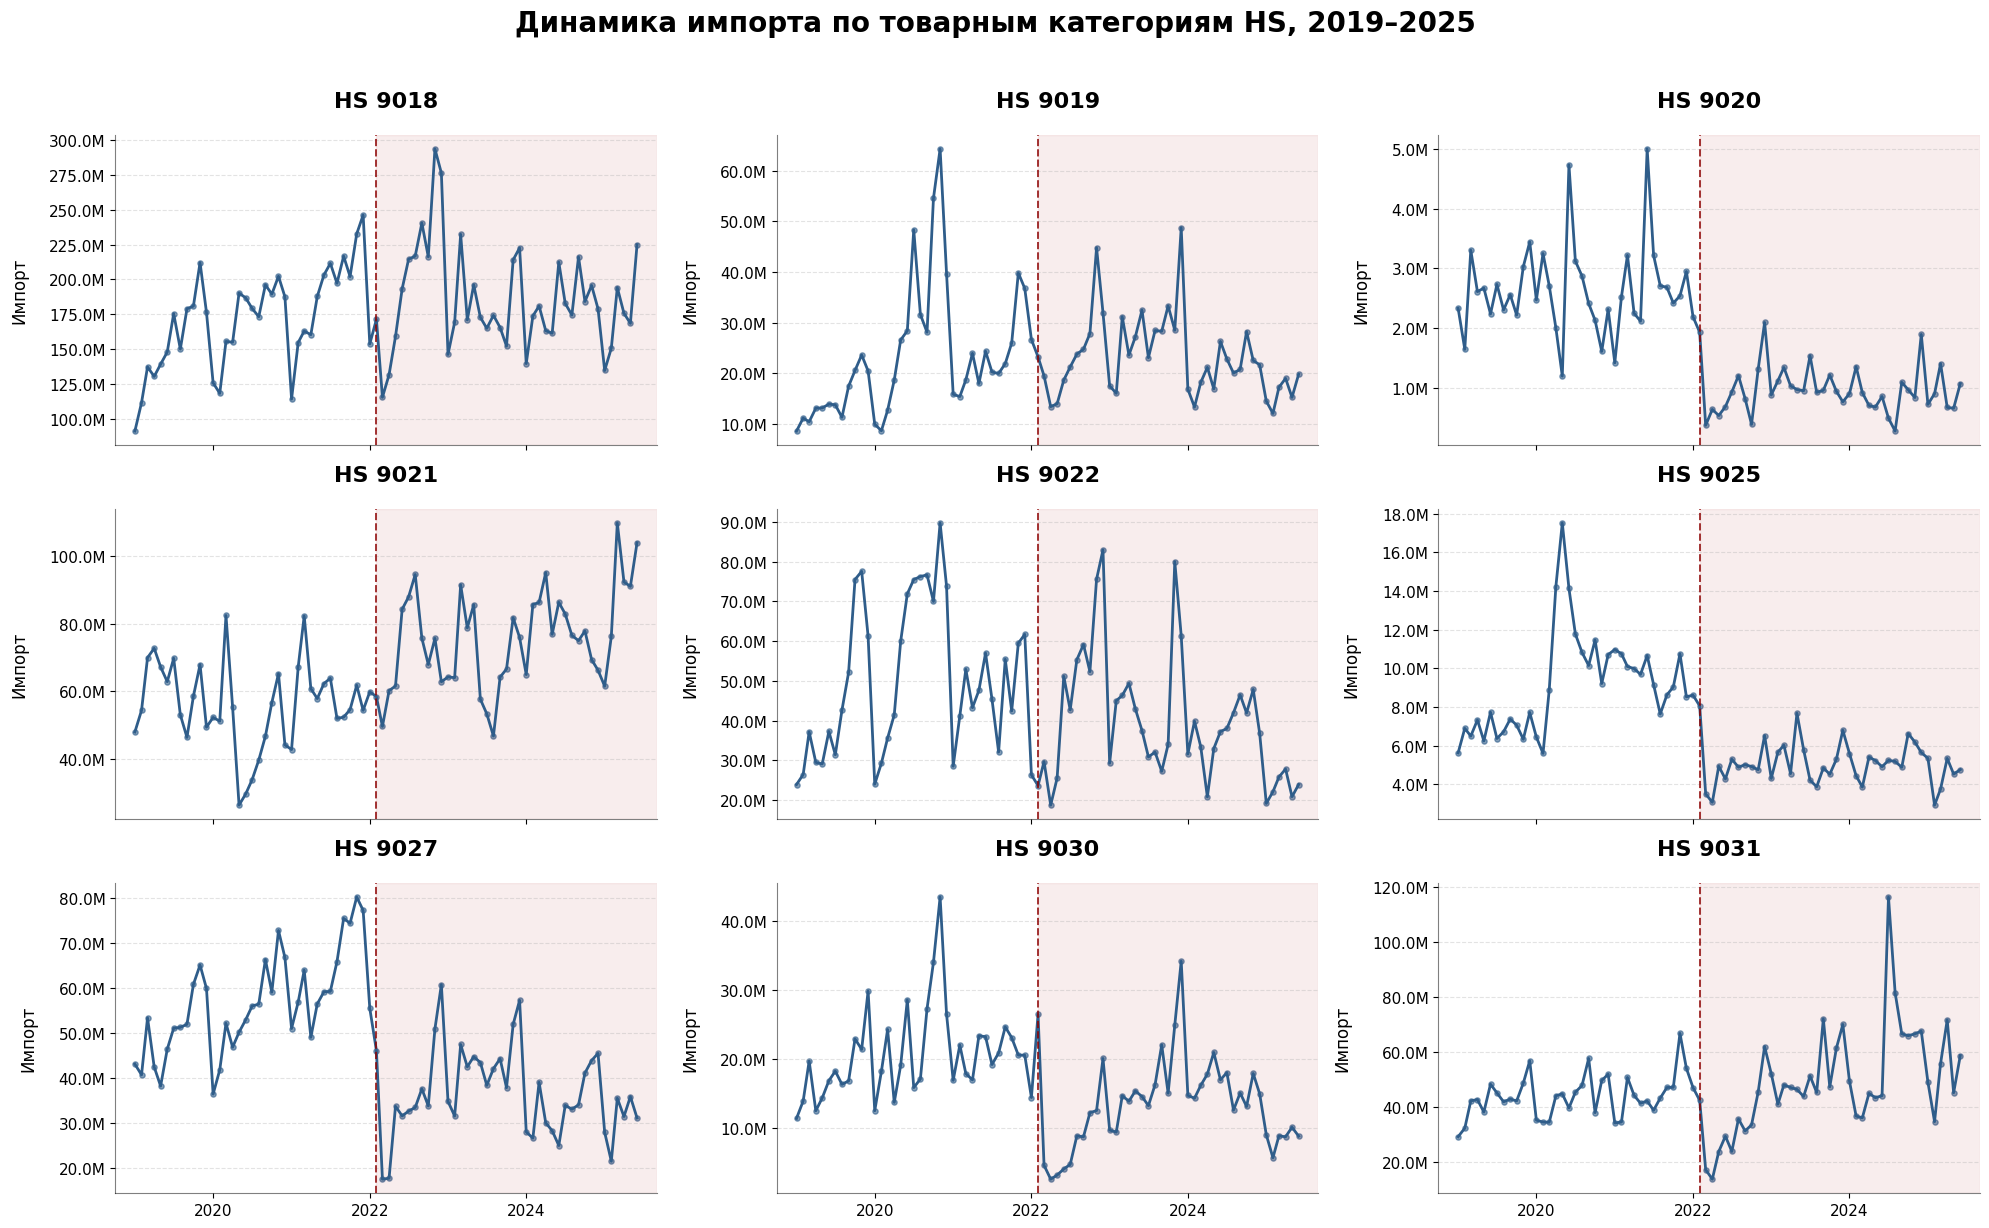

In [8]:
x_min = hs_month["rep_date"].min()
x_max = hs_month["rep_date"].max()

# одинаковые отступы слева и справа
x_pad = pd.DateOffset(months=3)
x_min_plot = x_min - x_pad
x_max_plot = x_max + x_pad

hs_list = sorted(hs_month["hs"].unique())

fig, axes = plt.subplots(3, 3, figsize=(20, 12), sharex=True)
axes = axes.flatten()

for ax, hs_code in zip(axes, hs_list):
    temp = hs_month[hs_month["hs"] == hs_code].copy()

    ax.plot(
        temp["rep_date"],
        temp["value"],
        color="#2F5D8A",
        linewidth=2.0
    )

    ax.scatter(
        temp["rep_date"],
        temp["value"],
        color="#2F5D8A",
        s=14,
        alpha=0.6
    )

    # одинаковая ось X с отступами
    ax.set_xlim(x_min_plot, x_max_plot)

    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(FuncFormatter(human_format))

    apply_style(
        ax,
        title=f"HS {hs_code}",
        ylabel="Импорт",
        shade_post=True, post_sanctions=False
    )

fig.suptitle(
    "Динамика импорта по товарным категориям HS, 2019–2025",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

fig.tight_layout()
save_figure(fig, "01_hs_small_multiples")

График small multiples показывает, что реакция различных товарных категорий на шок 2022 года была явно неоднородной. По ряду кодов, например 9020, 9025, 9027 и 9030, после 2022 года наблюдается заметное снижение стоимостного импорта и переход на более низкий уровень по сравнению с докризисным периодом. Напротив, по кодам 9018, 9021 и 9031 импорт в постсанкционный период либо сохраняется на сопоставимом уровне, либо даже демонстрирует рост в отдельные периоды. Категория 9019 выглядит относительно стабильной, без выраженного структурного перелома, хотя и с заметной месячной волатильностью. По 9022 можно видеть скорее ослабление и более нестабильную траекторию после 2022 года. В совокупности этот график показывает, что санкционный шок нельзя интерпретировать как одинаковый для всего медицинского оборудования: одни товарные группы сократились существенно, тогда как другие оказались более устойчивыми или даже усилили свое значение в структуре импорта.

#### ГРАФИК 2. СТРУКТУРА ИМПОРТА ПО HS ВО ВРЕМЕНИ

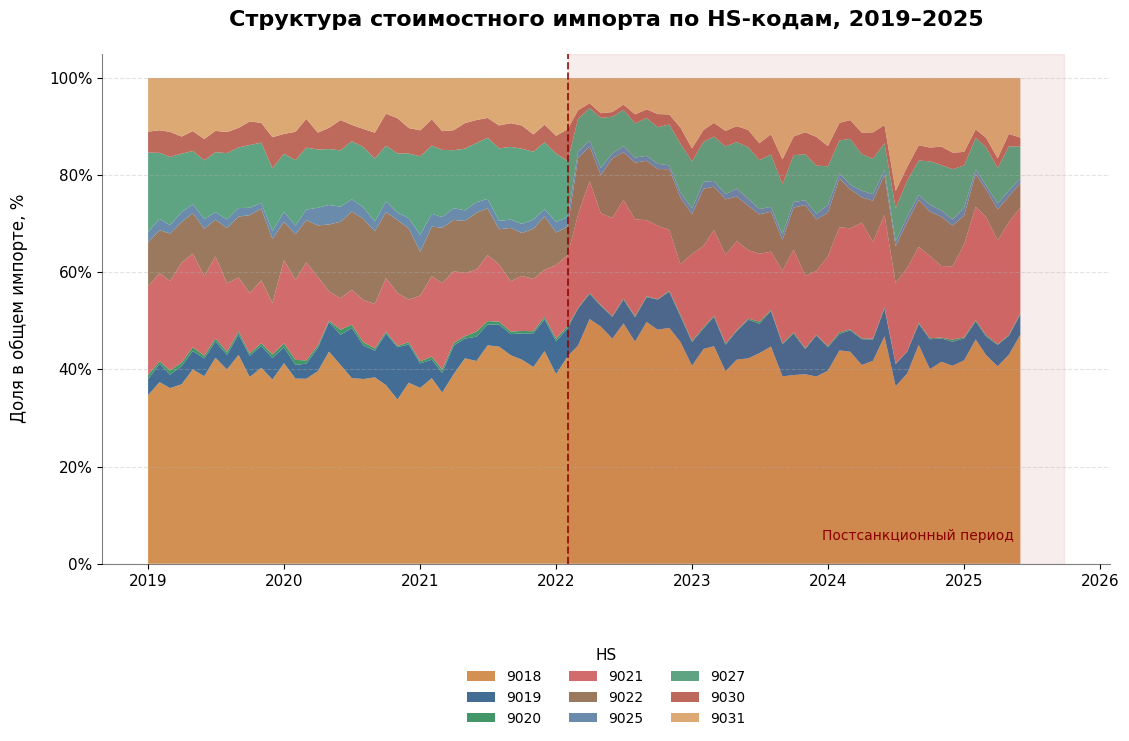

In [11]:
hs_colors = [
    "#CD853F",  # peru
    "#2F5D8A",  # сине-стальной
    "#2E8B57",  # sea green
    "#CD5C5C",  # indian red
    "#8F6A4C",  # приглушенный коричневый
    "#5B7FA3",  # светлее к синему
    "#4C9A74",  # светлее к зеленому
    "#B65A4A",  # темнее к красному
    "#D9A066"   # светлее к песочному
]

fig, ax = plt.subplots(figsize=(13, 7.5))

ax.stackplot(
    hs_shares.index,
    [hs_shares[col] for col in hs_shares.columns],
    labels=[str(col) for col in hs_shares.columns],
    colors=hs_colors[:len(hs_shares.columns)],
    alpha=0.90
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(PercentFormatter())

apply_style(
    ax,
    title="Структура стоимостного импорта по HS-кодам, 2019–2025",
    ylabel="Доля в общем импорте, %",
    shade_post=True
)

ax.legend(
    title="HS",
    frameon=False,
    fontsize=10,
    title_fontsize=11,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14)
)

fig.subplots_adjust(bottom=0.20)

save_figure(fig, "02_hs_share_stacked_area")

Stacked area chart подтверждает, что после 2022 года изменилась не только величина поставок по отдельным HS-кодам, но и внутренняя структура общего импорта. На протяжении всего периода крупнейшую долю занимает HS 9018, и после 2022 года его относительный вес даже усиливается, что говорит о росте значения этой категории в общей структуре стоимостного импорта. Одновременно уменьшается вклад некоторых других категорий, прежде всего 9020, 9025 и 9027, доли которых в постсанкционный период становятся более скромными. Категории 9021 и 9031, напротив, выглядят более значимыми, чем до 2022 года, особенно в отдельные участки постсанкционного периода. Таким образом, структурная перестройка импорта затронула не только географическое направление поставок, но и товарную композицию: после 2022 года импорт стал в большей степени концентрироваться в нескольких ключевых категориях оборудования, тогда как роль части других HS-кодов сократилась.


#### ГРАФИК 3. СРЕДНИЙ МЕСЯЧНЫЙ ИМПОРТ ПО HS: ДО И ПОСЛЕ

period,hs,2019–2021,2022–2025,delta_abs
6,9027,5.638570e+07,3.662122e+07,-1.976449e+07
4,9022,4.975985e+07,3.952177e+07,-1.023808e+07
7,9030,2.046814e+07,1.349548e+07,-6.972658e+06
5,9025,9.117731e+06,5.086750e+06,-4.030981e+06
2,9020,2.625772e+06,9.755686e+05,-1.650204e+06
1,9019,2.319172e+07,2.316782e+07,-2.390013e+04
8,9031,4.380541e+07,4.912089e+07,5.315477e+06
0,9018,1.712221e+08,1.859262e+08,1.470407e+07
3,9021,5.603257e+07,7.525011e+07,1.921755e+07


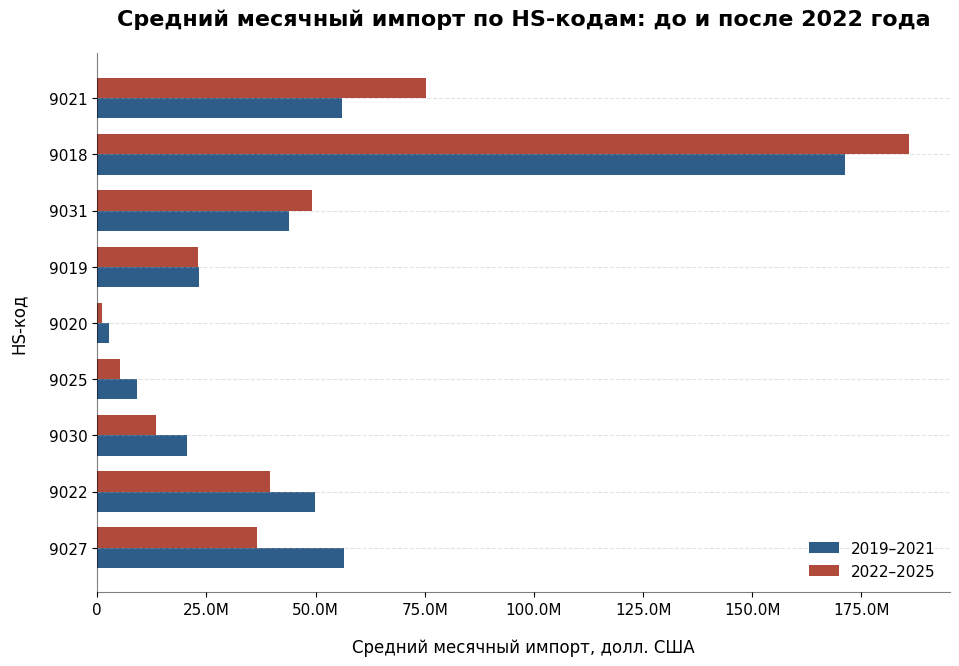

In [10]:
hs_period_avg = (
    hs_month.groupby(["hs", "period"], as_index=False)["value"]
    .mean()
)

hs_period_wide = (
    hs_period_avg.pivot(index="hs", columns="period", values="value")
    .reset_index()
)

hs_period_wide["delta_abs"] = hs_period_wide["2022–2025"] - hs_period_wide["2019–2021"]
hs_period_wide = hs_period_wide.sort_values("delta_abs", ascending=True)

display(hs_period_wide)


fig, ax = plt.subplots(figsize=(11, 7))

y = np.arange(len(hs_period_wide))
bar_h = 0.36

ax.barh(
    y - bar_h / 2,
    hs_period_wide["2019–2021"],
    height=bar_h,
    color="#2F5D8A",
    label="2019–2021"
)

ax.barh(
    y + bar_h / 2,
    hs_period_wide["2022–2025"],
    height=bar_h,
    color="#B04A3A",
    label="2022–2025"
)

ax.set_yticks(y)
ax.set_yticklabels(hs_period_wide["hs"].astype(str))
ax.xaxis.set_major_formatter(FuncFormatter(human_format))

apply_style(
    ax,
    title="Средний месячный импорт по HS-кодам: до и после 2022 года",
    xlabel="Средний месячный импорт, долл. США",
    ylabel="HS-код"
)

ax.legend(frameon=False, fontsize=11, loc="lower right")

save_figure(fig, "03_hs_pre_post_mean_import")

Сравнение средних месячных объемов импорта до и после 2022 года позволяет более четко зафиксировать направление изменений по каждой товарной категории. Наиболее заметный рост среднего импорта наблюдается по HS 9021, 9018 и 9031, что указывает на относительную устойчивость или даже расширение поставок в этих сегментах. В то же время по HS 9020, 9025, 9027, 9030 и 9022 фиксируется снижение средних месячных значений, причем по ряду позиций оно весьма существенное. Категория 9019 практически не меняется, что позволяет считать ее одной из наиболее стабильных с точки зрения среднего стоимостного импорта. Следовательно, в постсанкционный период импорт медицинского оборудования не просто сократился или перестроился в целом, а перераспределился между товарными категориями: часть из них усилила свое значение, тогда как другие заметно потеряли в стоимостном выражении.

#### ГРАФИК 4. ОТНОСИТЕЛЬНОЕ ИЗМЕНЕНИЕ ПО HS

period,hs,2019–2021,2022–2025,pct_change
2,9020,2.625772e+06,9.755686e+05,-62.846413
5,9025,9.117731e+06,5.086750e+06,-44.210352
6,9027,5.638570e+07,3.662122e+07,-35.052299
7,9030,2.046814e+07,1.349548e+07,-34.065911
4,9022,4.975985e+07,3.952177e+07,-20.574982
1,9019,2.319172e+07,2.316782e+07,-0.103055
0,9018,1.712221e+08,1.859262e+08,8.587714
8,9031,4.380541e+07,4.912089e+07,12.134293
3,9021,5.603257e+07,7.525011e+07,34.297105


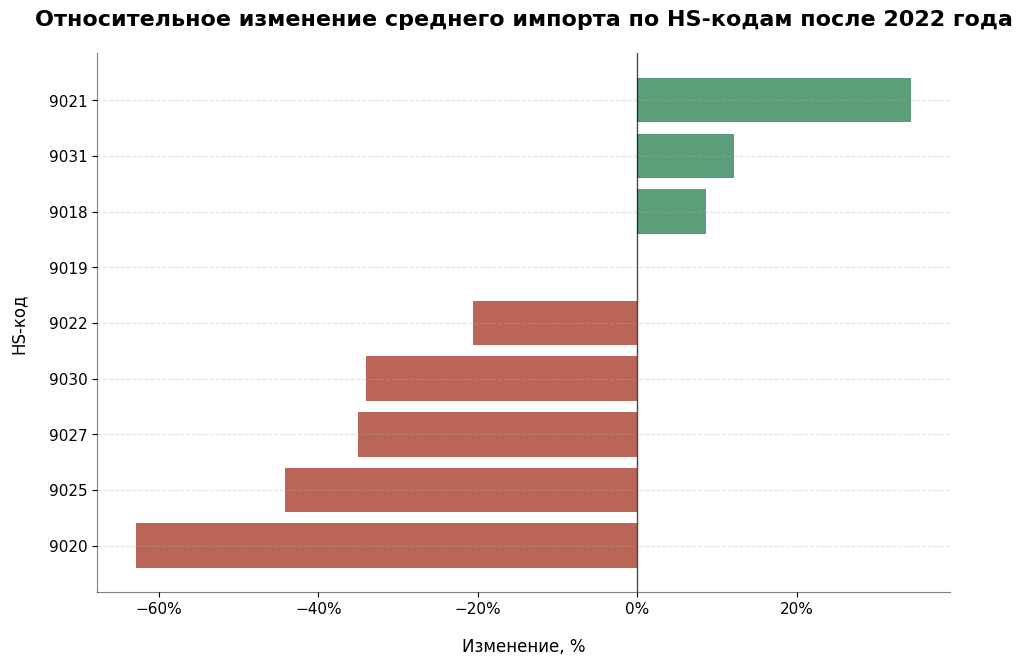

In [12]:
hs_period_wide["post_pre_ratio"] = np.where(
    hs_period_wide["2019–2021"] > 0,
    hs_period_wide["2022–2025"] / hs_period_wide["2019–2021"],
    np.nan
)

hs_period_wide["pct_change"] = (hs_period_wide["post_pre_ratio"] - 1) * 100
hs_period_wide = hs_period_wide.sort_values("pct_change", ascending=True)

display(hs_period_wide[["hs", "2019–2021", "2022–2025", "pct_change"]])

fig, ax = plt.subplots(figsize=(11, 7))

colors = np.where(hs_period_wide["pct_change"] >= 0, "#3E8E63", "#B04A3A")

ax.barh(
    hs_period_wide["hs"].astype(str),
    hs_period_wide["pct_change"],
    color=colors,
    alpha=0.85
)

ax.axvline(0, color="black", linewidth=1.0, alpha=0.7)
ax.xaxis.set_major_formatter(PercentFormatter())

apply_style(
    ax,
    title="Относительное изменение среднего импорта по HS-кодам после 2022 года",
    xlabel="Изменение, %",
    ylabel="HS-код"
)

save_figure(fig, "04_hs_pct_change_post_pre")

График относительных изменений позволяет ранжировать HS-коды по силе реакции на шок 2022 года. Наибольший положительный прирост показывает HS 9021, за которым следуют 9031 и 9018; это означает, что в этих категориях средний импорт после 2022 года оказался выше докризисного уровня. В противоположной части распределения находятся HS 9020, 9025, 9027, 9030 и 9022, причем наиболее сильное относительное сокращение наблюдается у 9020. Такое распределение результатов подтверждает, что воздействие санкционного давления на импорт медицинского оборудования было асимметричным: одни категории, вероятно, оказались более критичными или легче переориентировались на альтернативные каналы поставок, тогда как другие сильнее пострадали от разрыва прежних торговых связей, ограничений логистики и изменений в структуре внешнего предложения.

#### ГРАФИК 5. HEATMAP ИМПОРТА ПО HS И МЕСЯЦАМ